In [1]:
import random
import networkx as nx
import torch
import torch.nn as nn

from deep_ebm.utils_ebm import show_graph, evaluate_model
from deep_ebm.utils_ebm import save_graph, compare_graphs, show_graph_grid, compare_statistics
from deep_ebm.gnn_ebm import GraphDataset, GNN_EBM, train_one_epoch_pcd, gibbs_ministeps

from src.torch_erg import load_pglib_opf as lp
from src.torch_erg.samplers import GWGSampler, MHSampler, GWG_Hybrid_Sampler, MH_Hybrid_Sampler
from src.torch_erg.utils import laplacian_matrix
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle as pkl
from scipy.sparse.csgraph import connected_components
from scipy.sparse import csr_matrix

from Plots_and_utils.plots import *
from Plots_and_utils.other_g_stats import *

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [2]:
with open("Saved_models/2community_GNN_EBM_50e_2000GS.pkl", "rb") as f:
    model_deep= pkl.load(f)

new_model = GNN_EBM(hidden_dim=128, mp_steps=6, device=device, node_feat_dim=30)


In [3]:
new_model.load_state_dict(torch.load("Saved_models/Last_models/2community_gnn_ebm_model_2.pkl", map_location = device))

<All keys matched successfully>

In [4]:
with open("data/TOY2community_dataset/TOY2comms_GraphDataset.pkl", "rb") as f:
    dataset_2community = pkl.load(f)

In [5]:
reference = dataset_2community[0][0]
ref_feats = dataset_2community[0][1]

In [6]:
new_model(ref_feats, reference)

tensor(0.0240, grad_fn=<SqueezeBackward0>)

In [7]:
G_sparse = reference.cpu().numpy()  # Create sparse matrix
n_components = connected_components(csr_matrix(G_sparse))
print("Number of connected components in the graph:", n_components[0])

class MySampler(MH_Hybrid_Sampler):
    def __init__(self, backend: str, model: nn.Module):
        super().__init__(backend, model)
        self.model = model
    def observables(self, mtx):
        edges = torch.sum(mtx)/2
        triangles = torch.trace(torch.matmul(torch.matmul(mtx,mtx),mtx))/6
        #ac = torch.linalg.eigvalsh(laplacian_matrix(mtx))[1]
        return(torch.stack([edges, triangles]))

betas = torch.tensor([0., 0.])


Number of connected components in the graph: 1


In [8]:
#we freeze the node features as we do not need them, so that we can evaluate the model only on the adj matrix
class feat_encoded_model(nn.Module):
    def __init__(self, model, feats):
        super().__init__()
        self.model = model
        self.feats = feats.to(device)

    def forward(self,adj):
        return(self.model(self.feats, adj))

In [9]:
adj_model = feat_encoded_model(new_model, ref_feats)

sampler = MySampler(backend="cuda",model = adj_model)
obs = sampler.observables(reference)
print("observed observables: ", obs)
reference = reference.to(device)
params, _ = sampler.param_run(graph=reference,
                      observables=obs,
                      params=betas,
                      niter=10000,
                      params_update_every=3,
                      save_every=50,
                      save_params=True,
                      alpha=0.005,                      
                      min_change = 0.001)

CUDA backend not available falling back to cpu
observed observables:  tensor([109., 127.])


  0%|          | 12/10000 [00:00<01:29, 111.44it/s]

new ham is:  tensor(0.0240, grad_fn=<AddBackward0>)
old ham is:  tensor(0., grad_fn=<DotBackward0>)
new ham is:  tensor(0.0240, grad_fn=<AddBackward0>)
old ham is:  tensor(0., grad_fn=<DotBackward0>)
new ham is:  tensor(0.0240, grad_fn=<AddBackward0>)
old ham is:  tensor(0., grad_fn=<DotBackward0>)
new ham is:  tensor(0.0252, grad_fn=<AddBackward0>)
old ham is:  tensor(0., grad_fn=<DotBackward0>)
new ham is:  tensor(0.0251, grad_fn=<AddBackward0>)
old ham is:  tensor(0.0011, grad_fn=<DotBackward0>)
new ham is:  tensor(0.0251, grad_fn=<AddBackward0>)
old ham is:  tensor(0.0011, grad_fn=<DotBackward0>)
new ham is:  tensor(0.0257, grad_fn=<AddBackward0>)
old ham is:  tensor(0.0011, grad_fn=<DotBackward0>)
new ham is:  tensor(0.0258, grad_fn=<AddBackward0>)
old ham is:  tensor(0.0017, grad_fn=<DotBackward0>)
new ham is:  tensor(0.0258, grad_fn=<AddBackward0>)
old ham is:  tensor(0.0018, grad_fn=<DotBackward0>)
new ham is:  tensor(0.0258, grad_fn=<AddBackward0>)
old ham is:  tensor(0.0018, 

  0%|          | 37/10000 [00:00<01:25, 116.35it/s]

new ham is:  tensor(0.0256, grad_fn=<AddBackward0>)
old ham is:  tensor(0.0017, grad_fn=<DotBackward0>)
new ham is:  tensor(0.0257, grad_fn=<AddBackward0>)
old ham is:  tensor(0.0016, grad_fn=<DotBackward0>)
new ham is:  tensor(0.0256, grad_fn=<AddBackward0>)
old ham is:  tensor(0.0017, grad_fn=<DotBackward0>)
new ham is:  tensor(0.0256, grad_fn=<AddBackward0>)
old ham is:  tensor(0.0016, grad_fn=<DotBackward0>)
new ham is:  tensor(0.0256, grad_fn=<AddBackward0>)
old ham is:  tensor(0.0016, grad_fn=<DotBackward0>)
new ham is:  tensor(0.0256, grad_fn=<AddBackward0>)
old ham is:  tensor(0.0016, grad_fn=<DotBackward0>)
new ham is:  tensor(0.0253, grad_fn=<AddBackward0>)
old ham is:  tensor(0.0016, grad_fn=<DotBackward0>)
new ham is:  tensor(0.0252, grad_fn=<AddBackward0>)
old ham is:  tensor(0.0014, grad_fn=<DotBackward0>)
new ham is:  tensor(0.0253, grad_fn=<AddBackward0>)
old ham is:  tensor(0.0013, grad_fn=<DotBackward0>)
new ham is:  tensor(0.0253, grad_fn=<AddBackward0>)
old ham is: 

...

new ham is:  tensor(-143.7735, grad_fn=<AddBackward0>)
old ham is:  tensor(-141.8374, grad_fn=<DotBackward0>)
new ham is:  tensor(-143.7830, grad_fn=<AddBackward0>)
old ham is:  tensor(-141.8374, grad_fn=<DotBackward0>)
new ham is:  tensor(-143.7783, grad_fn=<AddBackward0>)
old ham is:  tensor(-141.8374, grad_fn=<DotBackward0>)
new ham is:  tensor(-141.2682, grad_fn=<AddBackward0>)
old ham is:  tensor(-141.8374, grad_fn=<DotBackward0>)
new ham is:  tensor(-142.5220, grad_fn=<AddBackward0>)
old ham is:  tensor(-141.2913, grad_fn=<DotBackward0>)
new ham is:  tensor(-142.5221, grad_fn=<AddBackward0>)
old ham is:  tensor(-141.2913, grad_fn=<DotBackward0>)
new ham is:  tensor(-143.7712, grad_fn=<AddBackward0>)
old ham is:  tensor(-142.5451, grad_fn=<DotBackward0>)
new ham is:  tensor(-145.7466, grad_fn=<AddBackward0>)
old ham is:  tensor(-143.7943, grad_fn=<DotBackward0>)
new ham is:  tensor(-143.2287, grad_fn=<AddBackward0>)
old ham is:  tensor(-143.7943, grad_fn=<DotBackward0>)
new ham is

100%|█████████▉| 9970/10000 [01:31<00:00, 153.65it/s]

new ham is:  tensor(-144.8221, grad_fn=<AddBackward0>)
old ham is:  tensor(-146.1329, grad_fn=<DotBackward0>)
new ham is:  tensor(-146.1074, grad_fn=<AddBackward0>)
old ham is:  tensor(-144.8453, grad_fn=<DotBackward0>)
new ham is:  tensor(-148.1308, grad_fn=<AddBackward0>)
old ham is:  tensor(-146.1306, grad_fn=<DotBackward0>)
new ham is:  tensor(-148.1262, grad_fn=<AddBackward0>)
old ham is:  tensor(-146.1306, grad_fn=<DotBackward0>)
new ham is:  tensor(-148.1308, grad_fn=<AddBackward0>)
old ham is:  tensor(-146.1306, grad_fn=<DotBackward0>)
new ham is:  tensor(-148.1308, grad_fn=<AddBackward0>)
old ham is:  tensor(-146.1306, grad_fn=<DotBackward0>)
new ham is:  tensor(-148.1285, grad_fn=<AddBackward0>)
old ham is:  tensor(-146.1306, grad_fn=<DotBackward0>)
new ham is:  tensor(-148.1238, grad_fn=<AddBackward0>)
old ham is:  tensor(-146.1306, grad_fn=<DotBackward0>)
new ham is:  tensor(-149.4155, grad_fn=<AddBackward0>)
old ham is:  tensor(-148.1470, grad_fn=<DotBackward0>)
new ham is

100%|██████████| 10000/10000 [01:31<00:00, 108.72it/s]

new ham is:  tensor(-151.1037, grad_fn=<AddBackward0>)
old ham is:  tensor(-149.0699, grad_fn=<DotBackward0>)
new ham is:  tensor(-151.1150, grad_fn=<AddBackward0>)
old ham is:  tensor(-149.0699, grad_fn=<DotBackward0>)
new ham is:  tensor(-151.1059, grad_fn=<AddBackward0>)
old ham is:  tensor(-149.0699, grad_fn=<DotBackward0>)
new ham is:  tensor(-151.1172, grad_fn=<AddBackward0>)
old ham is:  tensor(-149.0699, grad_fn=<DotBackward0>)
new ham is:  tensor(-148.4776, grad_fn=<AddBackward0>)
old ham is:  tensor(-149.0699, grad_fn=<DotBackward0>)
new ham is:  tensor(-147.1601, grad_fn=<AddBackward0>)
old ham is:  tensor(-148.5009, grad_fn=<DotBackward0>)
new ham is:  tensor(-148.4798, grad_fn=<AddBackward0>)
old ham is:  tensor(-147.1834, grad_fn=<DotBackward0>)
new ham is:  tensor(-145.8402, grad_fn=<AddBackward0>)
old ham is:  tensor(-147.1834, grad_fn=<DotBackward0>)
new ham is:  tensor(-147.8992, grad_fn=<AddBackward0>)
old ham is:  tensor(-145.8636, grad_fn=<DotBackward0>)
new ham is

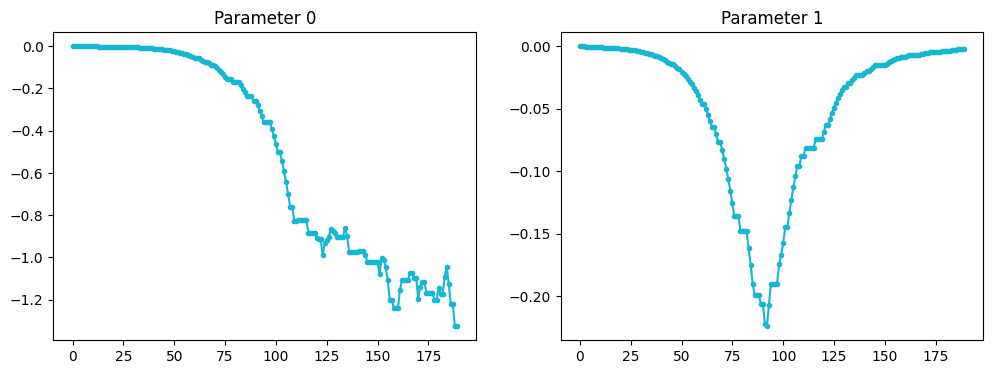

In [10]:
plot_params_iterations(params)

In [11]:
params_for_estimates = torch.stack(params[-50:]).mean(axis = 0)
params_for_estimates

tensor([-1.1151, -0.0085])

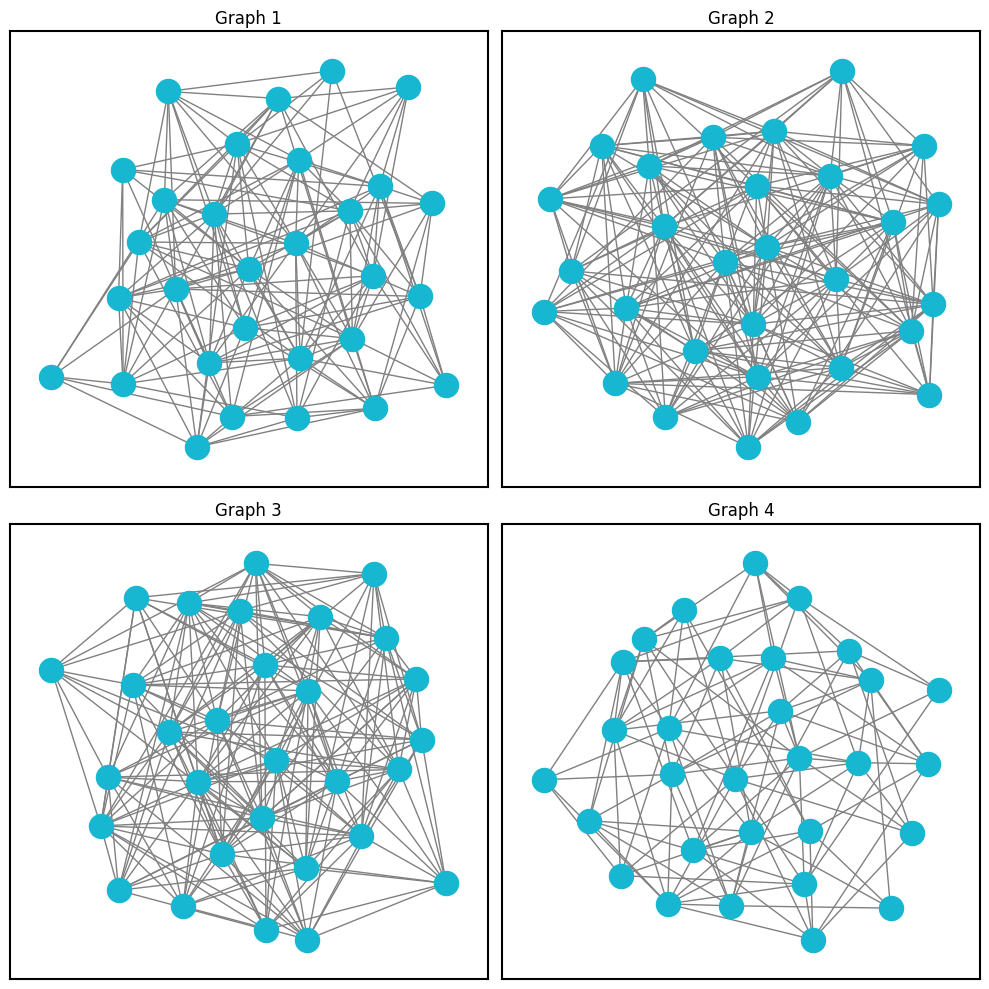

In [13]:
plot_random_graphs(_, 4)

In [17]:
observables, graphs = sampler.sample_run(graph=reference,
                      observables=obs,
                      params=params_for_estimates,
                      niter=5000,
                      save_every=50,
                      burn_in=0.2)

  1%|          | 39/5000 [00:00<00:24, 202.97it/s]

new ham is:  tensor(-121.4484, grad_fn=<AddBackward0>)
old ham is:  tensor(-122.6215, grad_fn=<DotBackward0>)
new ham is:  tensor(-122.5636, grad_fn=<AddBackward0>)
old ham is:  tensor(-121.4724, grad_fn=<DotBackward0>)
new ham is:  tensor(-120.3079, grad_fn=<AddBackward0>)
old ham is:  tensor(-121.4724, grad_fn=<DotBackward0>)
new ham is:  tensor(-119.1758, grad_fn=<AddBackward0>)
old ham is:  tensor(-120.3319, grad_fn=<DotBackward0>)
new ham is:  tensor(-120.2909, grad_fn=<AddBackward0>)
old ham is:  tensor(-119.1998, grad_fn=<DotBackward0>)
new ham is:  tensor(-120.2909, grad_fn=<AddBackward0>)
old ham is:  tensor(-119.1998, grad_fn=<DotBackward0>)
new ham is:  tensor(-120.2909, grad_fn=<AddBackward0>)
old ham is:  tensor(-119.1998, grad_fn=<DotBackward0>)
new ham is:  tensor(-120.2994, grad_fn=<AddBackward0>)
old ham is:  tensor(-119.1998, grad_fn=<DotBackward0>)
new ham is:  tensor(-118.0183, grad_fn=<AddBackward0>)
old ham is:  tensor(-119.1998, grad_fn=<DotBackward0>)
new ham is

  2%|▏         | 93/5000 [00:00<00:19, 248.63it/s]

new ham is:  tensor(-117.8910, grad_fn=<AddBackward0>)
old ham is:  tensor(-116.7914, grad_fn=<DotBackward0>)
new ham is:  tensor(-116.7589, grad_fn=<AddBackward0>)
old ham is:  tensor(-117.9149, grad_fn=<DotBackward0>)
new ham is:  tensor(-117.8741, grad_fn=<AddBackward0>)
old ham is:  tensor(-116.7829, grad_fn=<DotBackward0>)
new ham is:  tensor(-117.8910, grad_fn=<AddBackward0>)
old ham is:  tensor(-116.7829, grad_fn=<DotBackward0>)
new ham is:  tensor(-115.6269, grad_fn=<AddBackward0>)
old ham is:  tensor(-116.7829, grad_fn=<DotBackward0>)
new ham is:  tensor(-116.7505, grad_fn=<AddBackward0>)
old ham is:  tensor(-115.6508, grad_fn=<DotBackward0>)
new ham is:  tensor(-114.4863, grad_fn=<AddBackward0>)
old ham is:  tensor(-115.6508, grad_fn=<DotBackward0>)
new ham is:  tensor(-115.6014, grad_fn=<AddBackward0>)
old ham is:  tensor(-114.5103, grad_fn=<DotBackward0>)
new ham is:  tensor(-115.6268, grad_fn=<AddBackward0>)
old ham is:  tensor(-114.5103, grad_fn=<DotBackward0>)
new ham is

  2%|▏         | 123/5000 [00:00<00:18, 264.46it/s]

...

new ham is:  tensor(-124.3441, grad_fn=<AddBackward0>)
old ham is:  tensor(-123.2440, grad_fn=<DotBackward0>)
new ham is:  tensor(-122.1056, grad_fn=<AddBackward0>)
old ham is:  tensor(-123.2440, grad_fn=<DotBackward0>)
new ham is:  tensor(-123.2292, grad_fn=<AddBackward0>)
old ham is:  tensor(-122.1290, grad_fn=<DotBackward0>)
new ham is:  tensor(-123.2377, grad_fn=<AddBackward0>)
old ham is:  tensor(-122.1290, grad_fn=<DotBackward0>)
new ham is:  tensor(-123.2461, grad_fn=<AddBackward0>)
old ham is:  tensor(-122.1290, grad_fn=<DotBackward0>)
new ham is:  tensor(-123.2292, grad_fn=<AddBackward0>)
old ham is:  tensor(-122.1290, grad_fn=<DotBackward0>)
new ham is:  tensor(-123.2377, grad_fn=<AddBackward0>)
old ham is:  tensor(-122.1290, grad_fn=<DotBackward0>)
new ham is:  tensor(-120.9480, grad_fn=<AddBackward0>)
old ham is:  tensor(-122.1290, grad_fn=<DotBackward0>)
new ham is:  tensor(-122.0885, grad_fn=<AddBackward0>)
old ham is:  tensor(-120.9714, grad_fn=<DotBackward0>)
new ham is

 99%|█████████▉| 4961/5000 [00:25<00:00, 176.87it/s]

new ham is:  tensor(-119.7904, grad_fn=<AddBackward0>)
old ham is:  tensor(-118.6903, grad_fn=<DotBackward0>)
new ham is:  tensor(-119.7988, grad_fn=<AddBackward0>)
old ham is:  tensor(-118.6903, grad_fn=<DotBackward0>)
new ham is:  tensor(-120.9309, grad_fn=<AddBackward0>)
old ham is:  tensor(-119.8224, grad_fn=<DotBackward0>)
new ham is:  tensor(-120.9224, grad_fn=<AddBackward0>)
old ham is:  tensor(-119.8224, grad_fn=<DotBackward0>)
new ham is:  tensor(-122.0545, grad_fn=<AddBackward0>)
old ham is:  tensor(-120.9459, grad_fn=<DotBackward0>)
new ham is:  tensor(-122.0544, grad_fn=<AddBackward0>)
old ham is:  tensor(-120.9459, grad_fn=<DotBackward0>)
new ham is:  tensor(-122.0799, grad_fn=<AddBackward0>)
old ham is:  tensor(-120.9459, grad_fn=<DotBackward0>)
new ham is:  tensor(-123.2120, grad_fn=<AddBackward0>)
old ham is:  tensor(-122.1035, grad_fn=<DotBackward0>)
new ham is:  tensor(-123.2035, grad_fn=<AddBackward0>)
old ham is:  tensor(-122.1035, grad_fn=<DotBackward0>)
new ham is

100%|██████████| 5000/5000 [00:25<00:00, 194.13it/s]

new ham is:  tensor(-127.7148, grad_fn=<AddBackward0>)
old ham is:  tensor(-126.5977, grad_fn=<DotBackward0>)
new ham is:  tensor(-126.5658, grad_fn=<AddBackward0>)
old ham is:  tensor(-127.7383, grad_fn=<DotBackward0>)
new ham is:  tensor(-127.7063, grad_fn=<AddBackward0>)
old ham is:  tensor(-126.5892, grad_fn=<DotBackward0>)
new ham is:  tensor(-125.4337, grad_fn=<AddBackward0>)
old ham is:  tensor(-126.5892, grad_fn=<DotBackward0>)
new ham is:  tensor(-126.5658, grad_fn=<AddBackward0>)
old ham is:  tensor(-125.4572, grad_fn=<DotBackward0>)
new ham is:  tensor(-126.5743, grad_fn=<AddBackward0>)
old ham is:  tensor(-125.4572, grad_fn=<DotBackward0>)
new ham is:  tensor(-127.7234, grad_fn=<AddBackward0>)
old ham is:  tensor(-126.5977, grad_fn=<DotBackward0>)
new ham is:  tensor(-128.8470, grad_fn=<AddBackward0>)
old ham is:  tensor(-127.7468, grad_fn=<DotBackward0>)
new ham is:  tensor(-128.8469, grad_fn=<AddBackward0>)
old ham is:  tensor(-127.7468, grad_fn=<DotBackward0>)
new ham is

In [16]:
len(graphs)

1

In [30]:
def gibbs_ministeps2(adj: torch.Tensor, model: nn.Module, node_feats: torch.Tensor, device: torch.device, mini_steps: int) -> torch.Tensor:
    # run `mini_steps` individual mini-steps: sample a random pair each time
    # its formulation is equal to the standard MH one
    n = adj.shape[0]
    A = adj.clone()
    for _ in range(mini_steps):
        i = random.randrange(0, n)
        j = random.randrange(0, n)
        if i == j:
            continue
        a, b = min(i, j), max(i, j)
        A_prime = A.clone()
        A_prime[a, b] = 1.0 - A_prime[a, b]
        A_prime[b, a] = A_prime[a, b]
        with torch.no_grad():
            fA = model(node_feats.to(device), A.to(device))

            fApr = model(node_feats.to(device), A_prime.to(device))

            T = 0.2
            p = torch.sigmoid((fA - fApr) / T).item()
            
            if random.random() > p:
                #print(f"Accepted change: with delta {fA - fApr} and prob {p}")
                A = A_prime
    return A

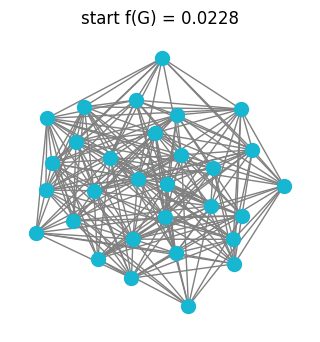

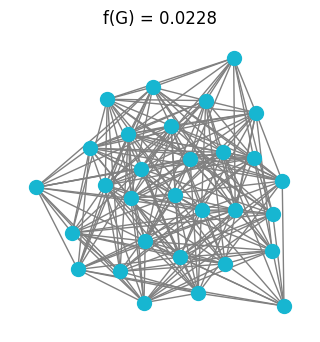

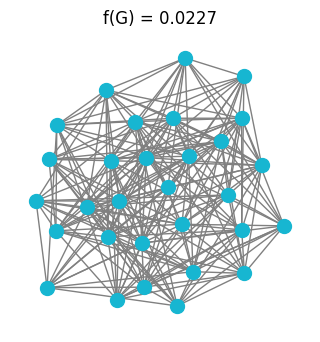

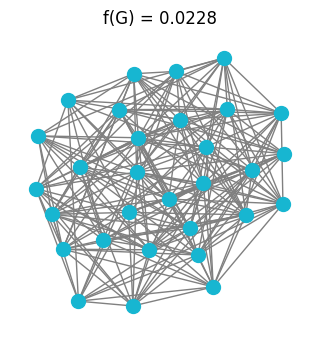

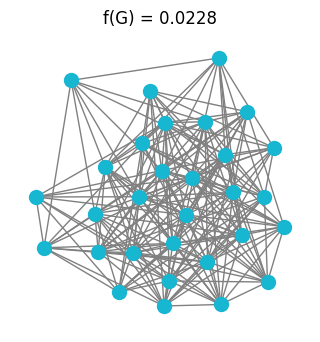

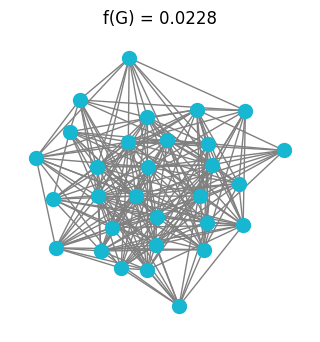

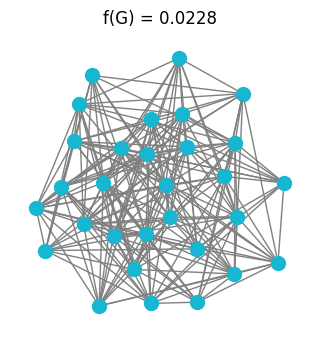

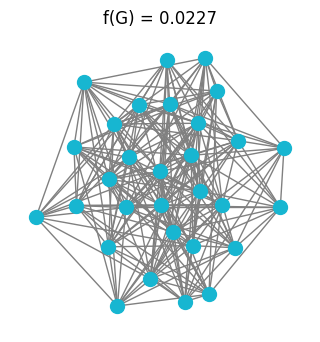

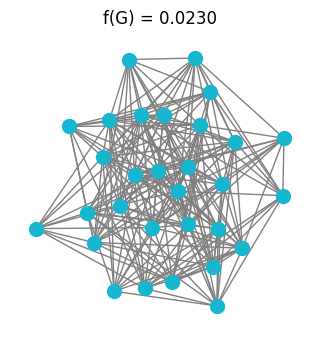

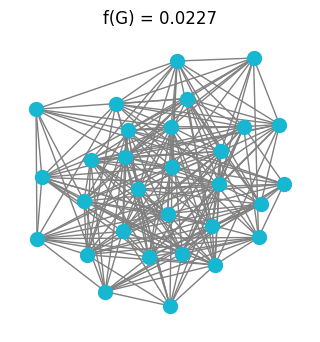

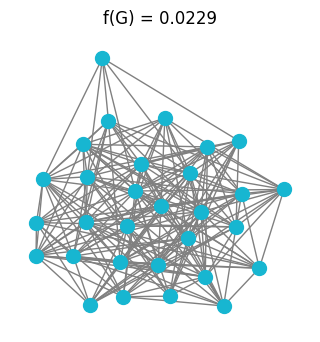

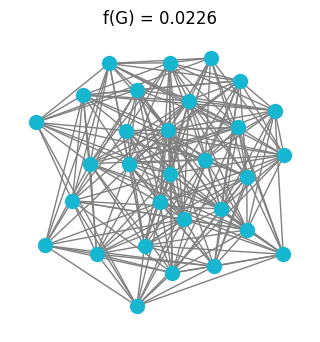

In [26]:
its = 10000
plot_every = 1000

energies_iterations = []

A, feats = dataset_2community[0]
A = torch.Tensor(nx.to_numpy_array(nx.binomial_graph(30, 0.5)))
energy = new_model(feats, A)
plot_graph(A, w = 3, h = 3, node_size=100, title=f"start f(G) = {energy:.4f}")

for i in range(its):
    A = gibbs_ministeps(A, new_model, feats.to(device), device, mini_steps=1)
    energy = new_model(feats, A)
    if i % plot_every == 0 or i == its - 1:
        plot_graph(A, w = 3, h = 3, node_size=100, title=f"f(G) = {energy:.4f}")
    energies_iterations.append(energy.item())

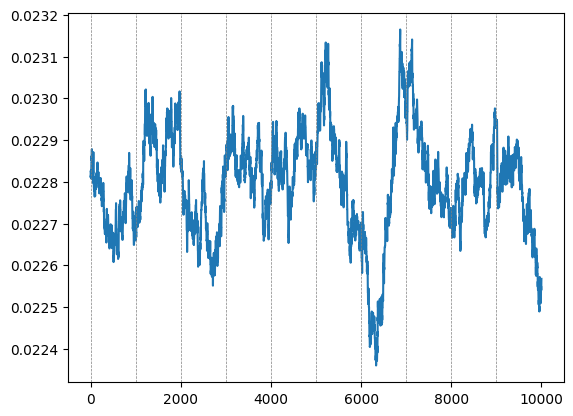

In [27]:
plt.plot(energies_iterations)
for i in range(its//plot_every):
    plt.axvline(i*plot_every, color='gray', linestyle='--', linewidth=0.5)

In [ ]:
generated = []
generated_tensors = []

with torch.no_grad():
    for i in range(20):
        A, feats = dataset_2community[i]
        A = torch.Tensor(nx.to_numpy_array(nx.binomial_graph(30, 0.5)))
        A_gen = gibbs_ministeps(A, model_deep, feats.to(device), device, mini_steps=1000)
        G_gen = nx.from_numpy_array(A_gen.cpu().numpy())
        generated.append(G_gen)
        generated_tensors.append(torch.tensor(A_gen.cpu().numpy()))

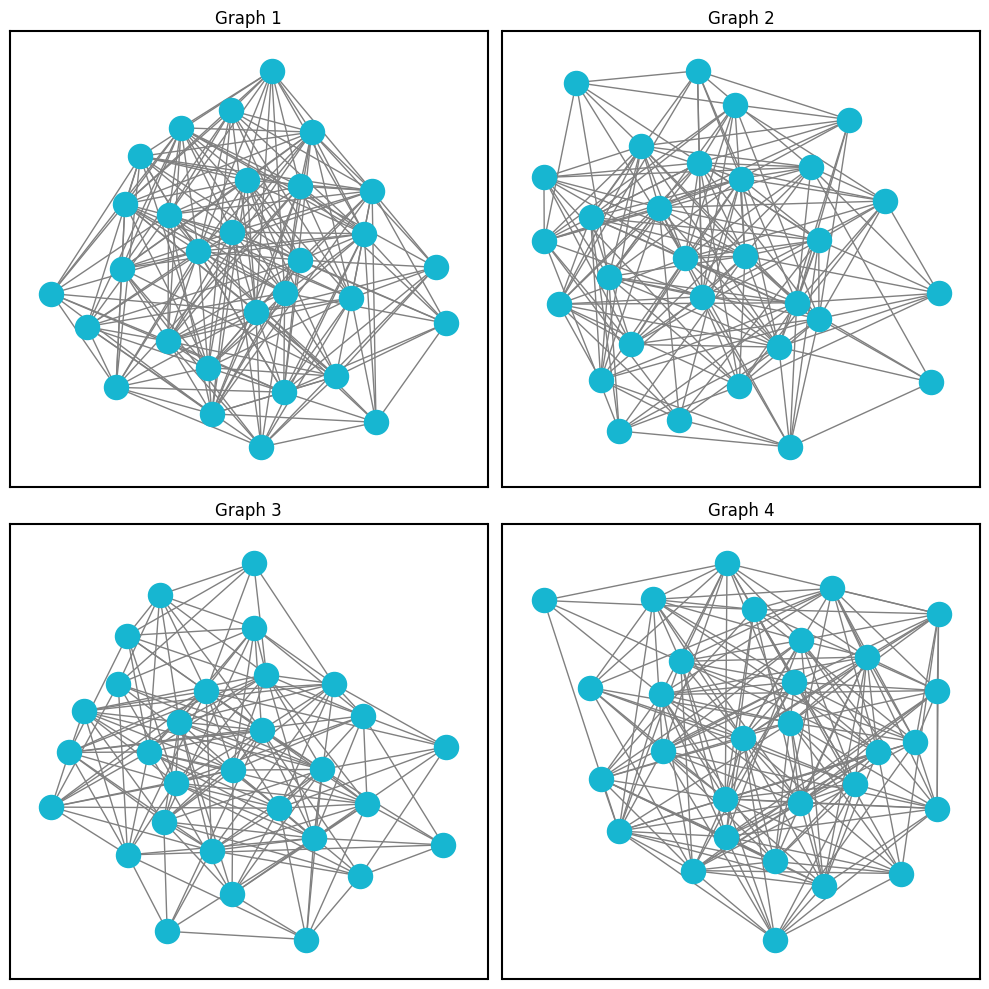

In [25]:
plot_random_graphs(generated_tensors, 4)